<a href="https://colab.research.google.com/github/dapenuela/ML_Supervisado_Clasificacion/blob/main/ML_Supervisado_Clasificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regresión Logística y algoritmos de clasificación
**Autor:** Diego Armando Peñuela Cárdenas

Especialización en Inteligencia Artificial. Práctica introductoria con Iris. Incluye un ejercicio binario y una comparación multiclase.

Este notebook es compatible con Google Colab y fue ejecutado en un entorno Python local para obtener las salidas incluidas. No se afirma una ejecución dentro de Colab.

**Para Colab:** Archivo > Subir notebook; cargar este archivo y seleccionar Entorno de ejecución > Ejecutar todas. No requiere descargar datos externos. Las librerías usadas normalmente están disponibles en Colab.

## 1. Importar librerías
Pandas organiza los datos; NumPy permite operaciones numéricas; Matplotlib genera gráficos y Scikit Learn proporciona los modelos y las métricas.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import sklearn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay)
print("Python:", sys.version.split()[0])
print("Scikit Learn:", sklearn.__version__)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)


Python: 3.13.16
Scikit Learn: 1.6.1
Pandas: 2.2.3
NumPy: 2.1.3
Matplotlib: 3.10.0


## 2. Cargar y revisar los datos
Iris contiene 150 flores, cuatro mediciones en centímetros y tres especies. La especie es la respuesta conocida o etiqueta. No eliminamos filas duplicadas automáticamente: mediciones iguales pueden corresponder a flores distintas.

In [2]:
iris = load_iris(as_frame=True)
X = iris.data
y = iris.target
print("Dimensiones:", X.shape)
print("Clases:", dict(enumerate(iris.target_names)))
print("Valores faltantes:", int(X.isna().sum().sum()))
print("Filas con mediciones duplicadas:", int(X.duplicated().sum()))
print("\nPrimeras filas:")
print(X.head().to_string())
print("\nCantidad por especie:")
print(y.map(dict(enumerate(iris.target_names))).value_counts().to_string())


Dimensiones: (150, 4)
Clases: {0: np.str_('setosa'), 1: np.str_('versicolor'), 2: np.str_('virginica')}
Valores faltantes: 0
Filas con mediciones duplicadas: 1

Primeras filas:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Cantidad por especie:
target
setosa        50
versicolor    50
virginica     50


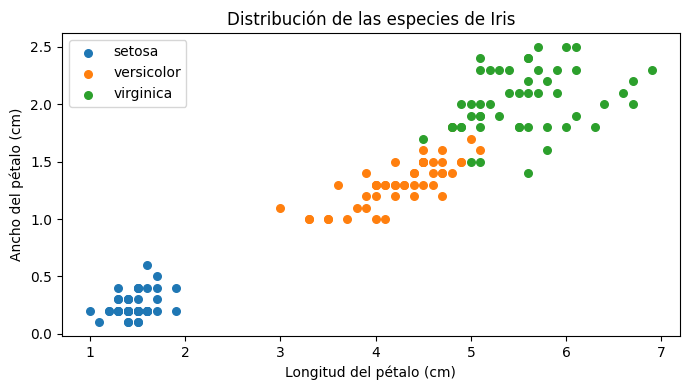

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
for clase, nombre in enumerate(iris.target_names):
    ax.scatter(X.loc[y == clase, "petal length (cm)"],
               X.loc[y == clase, "petal width (cm)"], label=nombre, s=30)
ax.set(xlabel="Longitud del pétalo (cm)", ylabel="Ancho del pétalo (cm)",
       title="Distribución de las especies de Iris")
ax.legend()
fig.tight_layout()
plt.show()


## 3. Regresión Logística binaria
Se usan solamente versicolor y virginica: 0 = versicolor, 1 = virginica. La Regresión Logística estima la probabilidad de clase 1 con la función sigmoide. La probabilidad se convierte en una clase usando el umbral 0,5. El escalador aprende únicamente del entrenamiento, dentro de un Pipeline.

In [4]:
mascara = y != 0
X_bin = X.loc[mascara]
y_bin = (y.loc[mascara] == 2).astype(int)
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_bin, y_bin, test_size=0.30, random_state=42, stratify=y_bin)
logistica_bin = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
logistica_bin.fit(Xb_train, yb_train)
prob_bin = logistica_bin.predict_proba(Xb_test)[:, 1]
pred_bin = (prob_bin >= 0.5).astype(int)
print("Entrenamiento:", len(yb_train), "Prueba:", len(yb_test))
print("Accuracy:", round(accuracy_score(yb_test, pred_bin), 4))
print("Precisión de virginica:", round(precision_score(yb_test, pred_bin), 4))
print("Recall de virginica:", round(recall_score(yb_test, pred_bin), 4))
print("F1 de virginica:", round(f1_score(yb_test, pred_bin), 4))
print("Matriz de confusión:")
print(confusion_matrix(yb_test, pred_bin))
print("\nEjemplos de probabilidades y clases:")
print(pd.DataFrame({"Real": yb_test.to_numpy(), "Prob_virginica": np.round(prob_bin, 4),
                    "Predicción": pred_bin}).head(8).to_string(index=False))


Entrenamiento: 70 Prueba: 30
Accuracy: 0.9
Precisión de virginica: 0.9286
Recall de virginica: 0.8667
F1 de virginica: 0.8966
Matriz de confusión:
[[14  1]
 [ 2 13]]

Ejemplos de probabilidades y clases:
 Real  Prob_virginica  Predicción
    0          0.0222           0
    0          0.0016           0
    1          0.5889           1
    0          0.0572           0
    0          0.0158           0
    1          0.8949           1
    1          0.9969           1
    1          0.9968           1


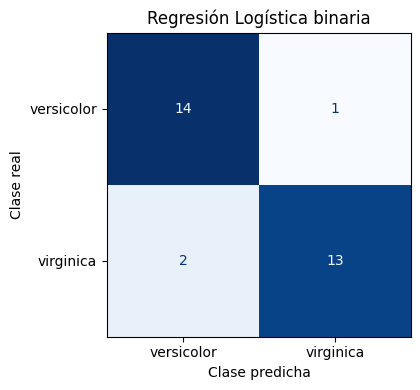

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    yb_test, pred_bin, display_labels=["versicolor", "virginica"],
    cmap="Blues", colorbar=False, ax=ax)
ax.set_title("Regresión Logística binaria")
ax.set_xlabel("Clase predicha")
ax.set_ylabel("Clase real")
fig.tight_layout()
plt.show()


## 4. División para la comparación multiclase
Todos los modelos usan la misma división: 105 ejemplos de entrenamiento y 45 de prueba. La estratificación mantiene 35 flores por clase en entrenamiento y 15 por clase en prueba. Se realiza validación cruzada de cinco particiones únicamente sobre el entrenamiento. No se ajustan parámetros mirando la prueba.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
print("Entrenamiento:", len(y_train), "Prueba:", len(y_test))
print("Clases en entrenamiento:", np.bincount(y_train))
print("Clases en prueba:", np.bincount(y_test))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


Entrenamiento: 105 Prueba: 45
Clases en entrenamiento: [35 35 35]
Clases en prueba: [15 15 15]


## 5. Definir los seis modelos
Se estandarizan las variables en Regresión Logística, SVM y KNN. Los árboles y Gaussian Naive Bayes trabajan con las mediciones originales. Los parámetros son elecciones didácticas fijadas antes de evaluar; no representan una búsqueda de la mejor configuración.

In [7]:
modelos = {
    "Regresión Logística": make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=1000)),
    "Decision Tree": DecisionTreeClassifier(max_depth=3, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=3, random_state=42),
    "SVM": make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1.0, gamma="scale")),
    "KNN": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "Naive Bayes": GaussianNB()
}
print("Modelos definidos:", list(modelos))


Modelos definidos: ['Regresión Logística', 'Decision Tree', 'Random Forest', 'SVM', 'KNN', 'Naive Bayes']


## 6. Entrenar y evaluar
Accuracy es la proporción global de aciertos. Precisión indica qué proporción de las predicciones de una clase es correcta; recall indica qué proporción de los ejemplos reales de esa clase fue identificada. El promedio macro da el mismo peso a cada especie. F1 combina precisión y recall. La validación cruzada reporta media y desviación estándar de F1 macro.

In [8]:
resultados = []
predicciones = {}
matrices = {}
for nombre, modelo in modelos.items():
    puntajes = cross_val_score(modelo, X_train, y_train, cv=cv, scoring="f1_macro")
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    predicciones[nombre] = pred
    matrices[nombre] = confusion_matrix(y_test, pred, labels=[0, 1, 2])
    resultados.append({
        "Modelo": nombre, "CV F1 media": puntajes.mean(), "CV F1 DE": puntajes.std(),
        "Accuracy": accuracy_score(y_test, pred),
        "Precisión macro": precision_score(y_test, pred, average="macro", zero_division=0),
        "Recall macro": recall_score(y_test, pred, average="macro", zero_division=0),
        "F1 macro": f1_score(y_test, pred, average="macro", zero_division=0),
        "Aciertos": int(np.sum(pred == y_test.to_numpy()))
    })
tabla = pd.DataFrame(resultados)
print(tabla.round(4).to_string(index=False))
mayor_cv = tabla["CV F1 media"].max()
print("\nMayor F1 medio de validación:", tabla.loc[
    np.isclose(tabla["CV F1 media"], mayor_cv), "Modelo"].tolist())


             Modelo  CV F1 media  CV F1 DE  Accuracy  Precisión macro  Recall macro  F1 macro  Aciertos
Regresión Logística       0.9809    0.0234    0.9111           0.9155        0.9111    0.9107        41
      Decision Tree       0.9519    0.0430    0.9778           0.9792        0.9778    0.9778        44
      Random Forest       0.9618    0.0357    0.9111           0.9155        0.9111    0.9107        41
                SVM       0.9714    0.0381    0.9333           0.9345        0.9333    0.9333        42
                KNN       0.9331    0.0488    0.9111           0.9298        0.9111    0.9095        41
        Naive Bayes       0.9809    0.0234    0.9111           0.9155        0.9111    0.9107        41

Mayor F1 medio de validación: ['Regresión Logística', 'Naive Bayes']


In [9]:
for nombre in modelos:
    print("\n" + nombre)
    print(classification_report(y_test, predicciones[nombre],
          labels=[0, 1, 2], target_names=iris.target_names, digits=4, zero_division=0))
    print("Matriz (filas reales, columnas predichas):")
    print(matrices[nombre])



Regresión Logística
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        15
  versicolor     0.8235    0.9333    0.8750        15
   virginica     0.9231    0.8000    0.8571        15

    accuracy                         0.9111        45
   macro avg     0.9155    0.9111    0.9107        45
weighted avg     0.9155    0.9111    0.9107        45

Matriz (filas reales, columnas predichas):
[[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]

Decision Tree
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        15
  versicolor     1.0000    0.9333    0.9655        15
   virginica     0.9375    1.0000    0.9677        15

    accuracy                         0.9778        45
   macro avg     0.9792    0.9778    0.9778        45
weighted avg     0.9792    0.9778    0.9778        45

Matriz (filas reales, columnas predichas):
[[15  0  0]
 [ 0 14  1]
 [ 0  0 15]]

Random Forest
              precision    

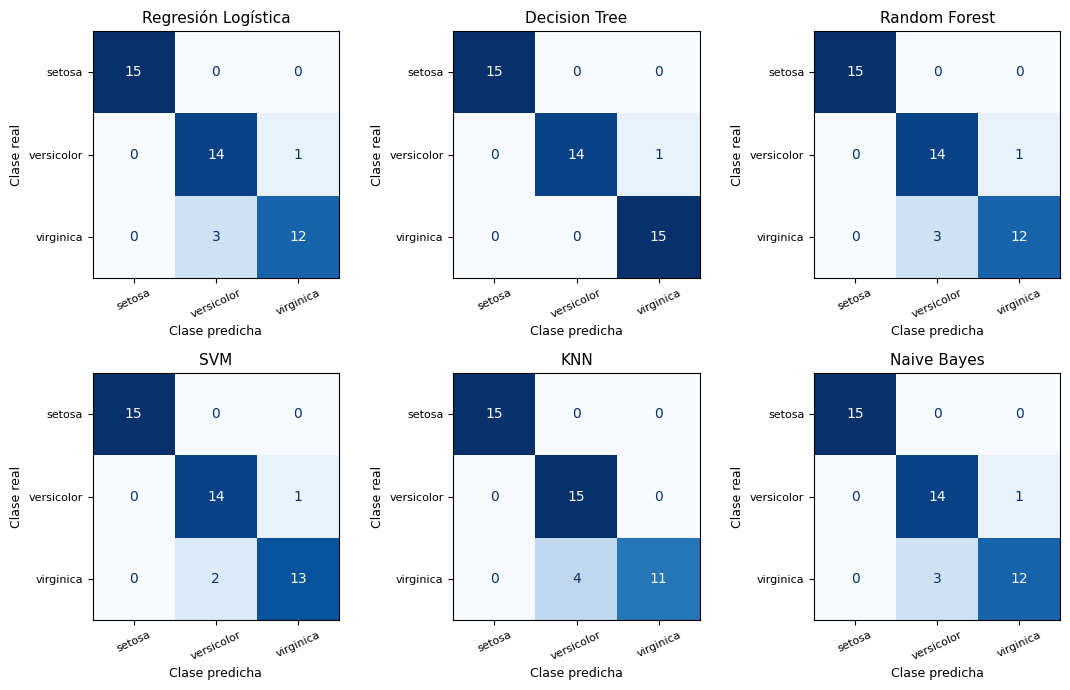

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for ax, (nombre, matriz) in zip(axes.ravel(), matrices.items()):
    ConfusionMatrixDisplay(matriz, display_labels=iris.target_names).plot(
        ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(nombre, fontsize=11)
    ax.set_xlabel("Clase predicha", fontsize=9)
    ax.set_ylabel("Clase real", fontsize=9)
    ax.tick_params(axis="x", rotation=25, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)
fig.tight_layout()
plt.show()


## 7. Reflexión sobre los resultados
Los resultados se interpretan para esta división concreta de Iris. Un modelo con mayor puntaje en esta prueba no es necesariamente mejor en otros datos. Con solo 45 ejemplos de prueba, un error modifica la exactitud en aproximadamente 2,22 puntos porcentuales.

El gráfico de pétalos ayuda a entender por qué algunas especies son más fáciles de separar y por qué versicolor y virginica pueden confundirse. La validación cruzada utiliza solo entrenamiento; la tabla de prueba sirve como comparación final y no para seguir ajustando los modelos.

## 8. Guardar la tabla
Esta celda crea un CSV en la carpeta de ejecución. En Colab se puede descargar desde el panel Archivos.

In [11]:
tabla.to_csv("resultados_clasificacion_iris.csv", index=False)
print("Guardado: resultados_clasificacion_iris.csv")


Guardado: resultados_clasificacion_iris.csv


## 9. Publicación en GitHub
El notebook todavía no está publicado por este trabajo. Para completar la entrega: crear o seleccionar un repositorio propio, usar Add file > Upload files, subir este .ipynb y guardar los cambios. Copiar la URL real del repositorio en el informe y comprobar el acceso del docente. No se incluye una dirección inventada.

## Referencias
Scikit-learn developers. (s. f.). *User guide*. https://scikit-learn.org/stable/user_guide.html

Scikit-learn developers. (s. f.). *load_iris*. https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html

Scikit-learn developers. (s. f.). *Metrics and scoring*. https://scikit-learn.org/stable/modules/model_evaluation.html